# Notebook 01 — Chargement des Données & Analyse Exploratoire (EDA)



Dataset Kaggle : `retrieval-engine-competition`

Fichiers utilisés :
- `docs.json` — 216 041 documents (id, title, text, tags, category)
- `queries_train.json` — 327 requêtes d'entraînement
- `qgts_train.json` — ground truth : `{query_id → {total_relevant_docs, relevant_doc_ids}}`
- `queries_test.json` — 141 requêtes de test (soumission Kaggle)

## 1. Imports et Configuration

In [1]:
import json
import os
import re
import string
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Téléchargement des ressources NLTK nécessaires
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
try:
    nltk.download('punkt_tab', quiet=True)
except Exception:
    pass

# Style des graphiques
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Chemins relatifs (exécuter depuis le dossier notebooks/)
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = Path(os.getenv('CHATODIT_DATA_DIR', NOTEBOOK_DIR / '../data')).resolve()
OUTPUTS_DIR = Path(os.getenv('CHATODIT_OUTPUTS_DIR', NOTEBOOK_DIR / '../outputs')).resolve()
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print('Imports OK')

Imports OK


## 2. Chargement des Données

In [2]:
required_files = [
    DATA_DIR / 'docs.json',
    DATA_DIR / 'queries_train.json',
    DATA_DIR / 'qgts_train.json',
    DATA_DIR / 'queries_test.json',
]
missing_files = [p for p in required_files if not p.exists()]
if missing_files:
    missing_list = '\n'.join(f'- {p}' for p in missing_files)
    raise FileNotFoundError(
        'Fichiers manquants dans DATA_DIR:\n'
        f'{missing_list}\n\n'
        'Placez les fichiers Kaggle dans le dossier data/ ou définissez la variable '
        'd\'environnement CHATODIT_DATA_DIR vers ce dossier.'
    )

print('Chargement de docs.json (~238 MB)...')
with open(DATA_DIR / 'docs.json', 'r', encoding='utf-8') as f:
    documents_raw = json.load(f)

print('Chargement de queries_train.json...')
with open(DATA_DIR / 'queries_train.json', 'r', encoding='utf-8') as f:
    queries_train = json.load(f)

print('Chargement de qgts_train.json...')
with open(DATA_DIR / 'qgts_train.json', 'r', encoding='utf-8') as f:
    qgts_train = json.load(f)  # dict : query_id -> {total_relevant_docs, relevant_doc_ids}

print('Chargement de queries_test.json...')
with open(DATA_DIR / 'queries_test.json', 'r', encoding='utf-8') as f:
    queries_test = json.load(f)

print(f'\nDocuments          : {len(documents_raw):,}')
print(f'Requêtes train     : {len(queries_train)}')
print(f'Ground truth train : {len(qgts_train)} entrées')
print(f'Requêtes test      : {len(queries_test)}')
print()

print('Exemple de document :')
print(json.dumps(documents_raw[0], indent=2, ensure_ascii=False))
print()
print('Exemple de requête train :')
print(json.dumps(queries_train[0], indent=2, ensure_ascii=False))
print()
print('Exemple de ground truth :')
first_qid = list(qgts_train.keys())[0]
print(f'query_id : {first_qid}')
print(json.dumps(qgts_train[first_qid], indent=2, ensure_ascii=False))

Chargement de docs.json (~238 MB)...


Chargement de queries_train.json...
Chargement de qgts_train.json...
Chargement de queries_test.json...

Documents          : 216,041
Requêtes train     : 327
Ground truth train : 327 entrées
Requêtes test      : 141

Exemple de document :
{
  "id": "6970cbf2-ffff-4c7b-b73d-52524000c232_145427",
  "text": "I try to install Complete MiKTeX 2.9 But there is this: Error: The operation could not be completed because the following file failed verification: C:...\\mikTex\\toptesi.tar.lzma There is the same with the basic version. How can I solve my problem?",
  "title": "MikTex Download Failure - toptesi.tar.lzma",
  "tags": [
    "miktex"
  ],
  "category": "tex"
}

Exemple de requête train :
{
  "id": "961c4349-8cf1-4ef1-89cc-24d20bb9d000_67878",
  "text": "Want to try reformatting Damaged SD Card",
  "title": "",
  "tags": [
    "linux",
    "development"
  ],
  "category": "android"
}

Exemple de ground truth :
query_id : 961c4349-8cf1-4ef1-89cc-24d20bb9d000_67878
{
  "total_relevant_doc

In [3]:
df_docs    = pd.DataFrame(documents_raw)
df_queries = pd.DataFrame(queries_train)
df_test    = pd.DataFrame(queries_test)

print('Champs df_docs    :', list(df_docs.columns))
print('Champs df_queries :', list(df_queries.columns))
df_docs.head(3)

Champs df_docs    : ['id', 'text', 'title', 'tags', 'category']
Champs df_queries : ['id', 'text', 'title', 'tags', 'category']


,id,text,title,tags,category
0,6970cbf2-ffff-4c7b-b73d-52524000c232_145427,I try to install Complete MiKTeX 2.9 But there...,MikTex Download Failure - toptesi.tar.lzma,[miktex],tex
1,667220d0-66be-4059-ae60-b9df15d285f7_77850,I'm trying to get a launcher working for the W...,Launcher for a Python program that requires ex...,"[gnome3, python, path, cd]",unix
2,e5608645-f23d-4cf4-bda6-46071510ebb0_84546,Its unclear as to whether this trait means tha...,"How does the ""Double damage in combat"" trait w...",[ftl-faster-than-light],gaming


### 2.1 Vérification de la Qualité des Données

In [4]:
# Valeurs nulles
print('=== Valeurs nulles par colonne ===')
print(df_docs.isnull().sum())
print()

# Doublons sur le champ id
nb_doublons = df_docs['id'].duplicated().sum()
print(f'Doublons sur le champ `id` : {nb_doublons}')

# Vérification des types
print()
print('Vérification du champ `tags` (doit être une liste) :')
print(df_docs['tags'].apply(type).value_counts())

=== Valeurs nulles par colonne ===
id          0
text        0
title       0
tags        0
category    0
dtype: int64

Doublons sur le champ `id` : 0

Vérification du champ `tags` (doit être une liste) :


tags
<class 'list'>    216041
Name: count, dtype: int64


## 3. Construction du Champ `content`

In [5]:
def build_content(row):
    """Concatène title, text et tags en un seul champ content."""
    tags_str = ' '.join(row['tags']) if isinstance(row['tags'], list) else str(row['tags'])
    return f"{row['title']} {row['text']} {tags_str}"

df_docs['content'] = df_docs.apply(build_content, axis=1)

print('Exemple de champ content :')
print(df_docs['content'].iloc[0][:300], '...')

Exemple de champ content :
MikTex Download Failure - toptesi.tar.lzma I try to install Complete MiKTeX 2.9 But there is this: Error: The operation could not be completed because the following file failed verification: C:...\mikTex\toptesi.tar.lzma There is the same with the basic version. How can I solve my problem? miktex ...


### 3.1 Preprocessing — `content_clean`

In [6]:
STOP_WORDS = set(stopwords.words('english'))

def preprocess(text):
    """Lowercasing, suppression ponctuation, filtrage stopwords."""
    # Lowercasing
    text = text.lower()
    # Suppression de la ponctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    # Suppression des chiffres isolés
    text = re.sub(r'\b\d+\b', '', text)
    # Tokenisation
    tokens = word_tokenize(text)
    # Filtrage des stopwords et tokens courts
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

df_docs['content_clean'] = df_docs['content'].apply(preprocess)

print('Exemple content_clean :')
print(df_docs['content_clean'].iloc[0][:300], '...')

Exemple content_clean :
miktex download failure toptesi tar lzma try install complete miktex error operation could completed following file failed verification miktex toptesi tar lzma basic version solve problem miktex ...


In [7]:
# Sauvegarde du DataFrame enrichi pour réutilisation dans les autres notebooks
df_docs.to_pickle('../data/df_docs_preprocessed.pkl')
print('DataFrame sauvegardé dans data/df_docs_preprocessed.pkl')

DataFrame sauvegardé dans data/df_docs_preprocessed.pkl


## 4. Analyse Exploratoire des Données (EDA)

### 4.1 Statistiques Globales

In [8]:
nb_docs       = len(df_docs)
nb_categories = df_docs['category'].nunique()
nb_q_train    = len(queries_train)
nb_q_test     = len(queries_test)
avg_tokens    = df_docs['content_clean'].apply(lambda x: len(x.split())).mean()
avg_relevant  = np.mean([v['total_relevant_docs'] for v in qgts_train.values()])

print('=== Statistiques du corpus ===')
print(f'Nombre de documents        : {nb_docs:,}')
print(f'Nombre de catégories       : {nb_categories}')
print(f'Catégories                 : {sorted(df_docs["category"].unique())}')
print(f'Requêtes entraînement      : {nb_q_train}')
print(f'Requêtes test              : {nb_q_test}')
print(f'Longueur moyenne (tokens)  : {avg_tokens:.1f}')
print(f'Docs pertinents / requête  : {avg_relevant:.1f} en moyenne')

=== Statistiques du corpus ===
Nombre de documents        : 216,041
Nombre de catégories       : 5
Catégories                 : ['android', 'gaming', 'programmers', 'tex', 'unix']
Requêtes entraînement      : 327
Requêtes test              : 141
Longueur moyenne (tokens)  : 83.8
Docs pertinents / requête  : 9.1 en moyenne


### 4.2 Distribution des Catégories

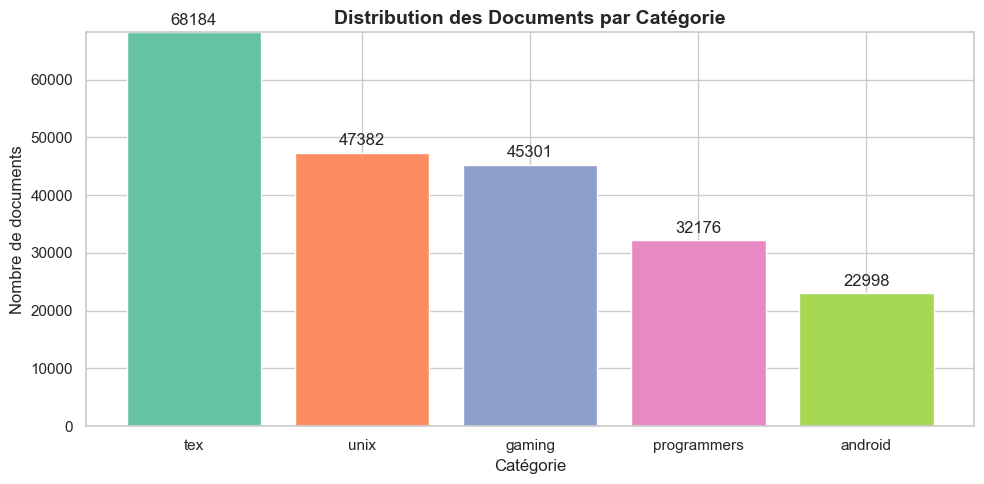

Figure sauvegardée.


In [9]:
cat_counts = df_docs['category'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cat_counts.index, cat_counts.values, color=sns.color_palette('Set2', len(cat_counts)))
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title('Distribution des Documents par Catégorie', fontsize=14, fontweight='bold')
ax.set_xlabel('Catégorie')
ax.set_ylabel('Nombre de documents')
ax.set_ylim(0, cat_counts.max() + 3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'category_distribution.png'), dpi=150)
plt.show()
print('Figure sauvegardée.')

### 4.3 Distribution de la Longueur des Documents

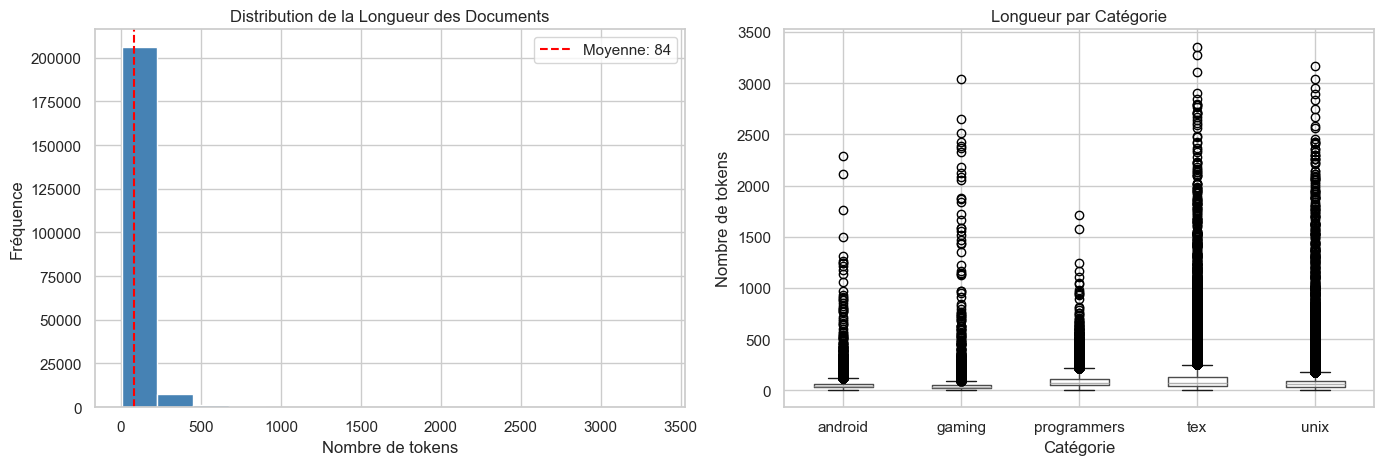

In [10]:
df_docs['nb_tokens'] = df_docs['content_clean'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global
axes[0].hist(df_docs['nb_tokens'], bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(df_docs['nb_tokens'].mean(), color='red', linestyle='--', label=f'Moyenne: {df_docs["nb_tokens"].mean():.0f}')
axes[0].set_title('Distribution de la Longueur des Documents')
axes[0].set_xlabel('Nombre de tokens')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Boxplot par catégorie
df_docs.boxplot(column='nb_tokens', by='category', ax=axes[1])
axes[1].set_title('Longueur par Catégorie')
axes[1].set_xlabel('Catégorie')
axes[1].set_ylabel('Nombre de tokens')
plt.suptitle('')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'document_length_distribution.png'), dpi=150)
plt.show()

### 4.4 Nuage de Mots du Corpus Global

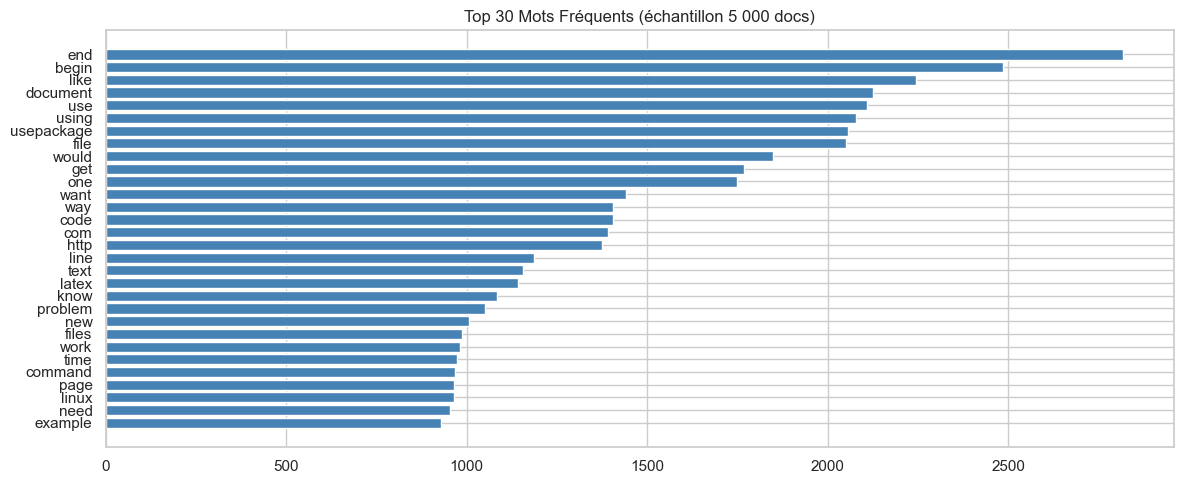

In [11]:
# Échantillon pour le wordcloud (évite saturation mémoire sur 216K docs)
sample_text = ' '.join(df_docs['content_clean'].sample(5000, random_state=42))

try:
    from wordcloud import WordCloud
    wc = WordCloud(width=1200, height=600, background_color='white',
                   max_words=120, colormap='viridis').generate(sample_text)
    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Nuage de Mots — Corpus (échantillon 5 000 docs)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUTS_DIR, 'wordcloud_corpus.png'), dpi=150)
    plt.show()
except ImportError:
    from collections import Counter
    top_words = Counter(sample_text.split()).most_common(30)
    words, counts = zip(*top_words)
    plt.figure(figsize=(12, 5))
    plt.barh(list(words)[::-1], list(counts)[::-1], color='steelblue')
    plt.title('Top 30 Mots Fréquents (échantillon 5 000 docs)')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUTS_DIR, 'top_words.png'), dpi=150)
    plt.show()

### 4.5 Analyse des Requêtes d'Entraînement

In [12]:
def build_query_text(q):
    parts = [q.get('text', ''), q.get('title', '')]
    if q.get('tags'):
        parts.append(' '.join(q['tags']))
    return ' '.join(p for p in parts if p).strip()

df_queries['query_text']  = df_queries.apply(build_query_text, axis=1)
df_queries['query_len']   = df_queries['query_text'].apply(lambda q: len(q.split()))
df_queries['nb_relevant'] = df_queries['id'].apply(
    lambda qid: qgts_train.get(qid, {}).get('total_relevant_docs', 0)
)

print('=== Statistiques des requêtes d\'entraînement ===')
print(f'Longueur moyenne    : {df_queries["query_len"].mean():.1f} mots')
print(f'Min / Max longueur  : {df_queries["query_len"].min()} / {df_queries["query_len"].max()}')
print(f'Docs pertinents moy : {df_queries["nb_relevant"].mean():.1f}')
print()
df_queries[['id', 'query_text', 'category', 'query_len', 'nb_relevant']].head(5)

=== Statistiques des requêtes d'entraînement ===
Longueur moyenne    : 11.4 mots
Min / Max longueur  : 3 / 31
Docs pertinents moy : 9.1



,id,query_text,category,query_len,nb_relevant
0,961c4349-8cf1-4ef1-89cc-24d20bb9d000_67878,Want to try reformatting Damaged SD Card linux...,android,9,4
1,4008ed78-e66e-4d89-9c3b-c79bd1cf6fc9_366,"Convince grep to output all lines, not just th...",unix,15,5
2,d5a95b09-e8ea-44dd-993d-347ed418e1f1_15138,How can I automatically reject some types of c...,android,11,4
3,3e66798a-b7fd-41b5-8bc0-33b3d7ce2aca_177487,Left and right braces on different lines of al...,tex,12,15
4,f5f944d2-277a-481d-ab09-612890402ded_137489,How do you get the purple shark fin? skyrim,gaming,9,6


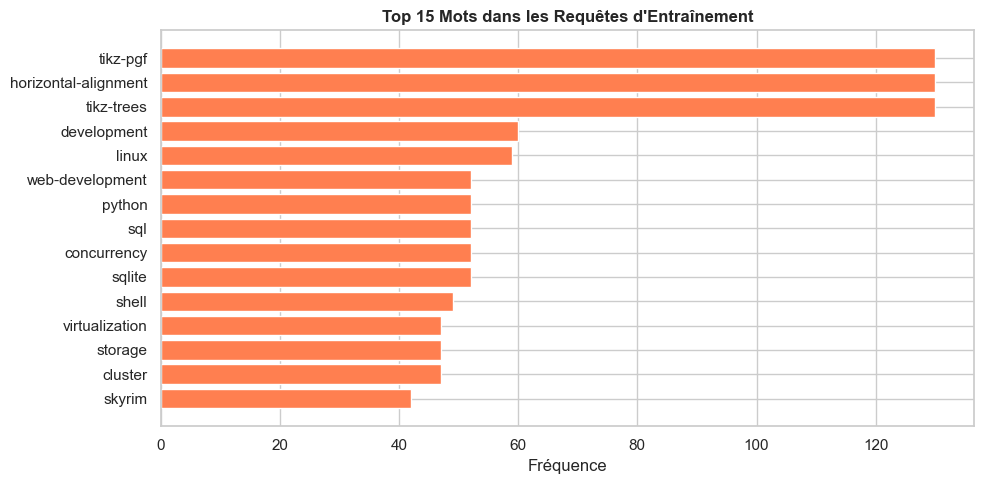

In [13]:
from collections import Counter

query_tokens = ' '.join(df_queries['query_text']).lower().split()
query_tokens = [t for t in query_tokens if t not in STOP_WORDS and len(t) > 2]
top_q_words  = Counter(query_tokens).most_common(15)

words, counts = zip(*top_q_words)
plt.figure(figsize=(10, 5))
plt.barh(list(words)[::-1], list(counts)[::-1], color='coral')
plt.title('Top 15 Mots dans les Requêtes d\'Entraînement', fontweight='bold')
plt.xlabel('Fréquence')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'query_top_words.png'), dpi=150)
plt.show()

## 5. Résumé

| Statistique | Valeur |
|-------------|--------|
| Nombre de documents | 216 041 |
| Catégories | tex, unix, gaming, programmers, android |
| Requêtes d'entraînement | 327 |
| Requêtes de test | 141 |
| Format ground truth | `{query_id: {total_relevant_docs, relevant_doc_ids: [{doc_id, relevance}]}}` |
| Docs pertinents moy / requête | ~4-5 |
| Titres vides | nombreux (utiliser `text` + `tags` comme texte de requête) |

**Livrables :**
- `data/df_docs_preprocessed.pkl` — DataFrame avec `content` et `content_clean`
- `outputs/category_distribution.png`
- `outputs/document_length_distribution.png`
- `outputs/wordcloud_corpus.png`
- `outputs/query_top_words.png`